# Face Recognition Attendance Pipeline

End to end pipeline for a 1:N face recognition attendance system: detection, alignment,
embedding extraction, database enrollment, similarity analysis, threshold calibration,
embedding space visualization, and simulated recognition testing.

The notebook runs in two modes depending on data availability:

- Real mode: photos found under `data/employees/<name>/*.jpg` are used directly with the
  InsightFace pipeline.
- Synthetic mode: if no real photos are found (fresh clone, no camera data yet) or the
  model cannot be loaded, a synthetic embedding space is generated so every downstream
  analysis (similarity distributions, threshold calibration, visualizations) still runs
  and produces representative results. Replace with real employee photos to get final
  production numbers.

Outputs (models, embeddings, figures, calibration values) are written to `output/`.

In [1]:
import os
os.environ["INSIGHTFACE_HOME"] = os.path.abspath(os.path.join("..", "output", "models"))

In [2]:
import os
import sys
import json
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.utils import load_config, read_image, bgr_to_rgb, draw_face_box, list_employee_folders, ensure_dirs
from src.database import EmployeeDatabase

CONFIG = load_config(os.path.join("..", "config.yaml"))

PATHS = CONFIG["paths"]
EMPLOYEE_DIR = os.path.join("..", PATHS["employee_data"])
OUTPUT_DIR = os.path.join("..", "output")
VIZ_DIR = os.path.join("..", PATHS["visualizations"])
EMB_DB_PATH = os.path.join("..", PATHS["embeddings_db"])
CALIBRATION_PATH = os.path.join("..", PATHS["calibration_file"])

ensure_dirs(VIZ_DIR, os.path.dirname(EMB_DB_PATH), os.path.join("..", PATHS["models_dir"]))

sns.set_theme(style="darkgrid", rc={"figure.facecolor": "#0E1117", "axes.facecolor": "#161A25",
                                      "axes.edgecolor": "#2A2F3E", "grid.color": "#2A2F3E",
                                      "text.color": "#E6E6E6", "axes.labelcolor": "#E6E6E6",
                                      "xtick.color": "#9AA1B4", "ytick.color": "#9AA1B4"})
PALETTE = ["#6C5CE7", "#33D399", "#FFBE5C", "#FF6B6B", "#4FC3F7", "#F06292"]

EMBEDDING_DIM = 512
np.random.seed(42)

In [3]:
import os
os.environ["INSIGHTFACE_HOME"] = os.path.abspath(os.path.join("..", "output", "models"))

## 1. Initialize the Face Recognition Engine

`FaceEngine` wraps InsightFace (`buffalo_l`: SCRFD detector + ArcFace recognition model).
If the model cannot be initialized (no internet access to download weights, or the
package is not installed in this environment), the notebook automatically falls back to
synthetic mode for the remaining sections.

In [4]:
engine = None
engine_error = None

try:
    from src.face_engine import FaceEngine
    model_cfg = CONFIG["model"]
    engine = FaceEngine(
        model_name=model_cfg["name"],
        detection_size=tuple(model_cfg["detection_size"]),
        ctx_id=model_cfg["ctx_id"],
    )
    print("FaceEngine initialized successfully with model:", model_cfg["name"])
except Exception as exc:
    engine_error = str(exc)
    print("FaceEngine could not be initialized, falling back to synthetic mode.")
    print("Reason:", engine_error)

FaceEngine initialized successfully with model: buffalo_l


## 2. Load Employee Data

Scans `data/employees/<employee_name>/*.jpg`. Each subfolder is treated as one employee
identity with one or more enrollment photos.

In [5]:
employee_folders = list_employee_folders(EMPLOYEE_DIR)
use_real_data = engine is not None and len(employee_folders) >= 2

print(f"Employee folders found: {len(employee_folders)}")
for name, images in employee_folders.items():
    print(f"  - {name}: {len(images)} photo(s)")

DATA_MODE = "real" if use_real_data else "synthetic"
print("\nData mode:", DATA_MODE)
if DATA_MODE == "synthetic":
    print("Add at least 2 employee folders with photos under data/employees/ to switch to real mode.")

Employee folders found: 3
  - ghani: 5 photo(s)
  - nadia: 5 photo(s)
  - nazril: 5 photo(s)

Data mode: real


## 3. Build the Embedding Set

Real mode runs every photo through detection, alignment and ArcFace embedding extraction.

Synthetic mode generates a realistic embedding space: each identity gets a random unit
direction in 512-D space, and samples are drawn around that direction with additive
noise, which mimics how real embeddings from the same person cluster tightly while
different people spread apart on the hypersphere.

In [6]:
records = {}

if DATA_MODE == "real":
    for name, image_paths in employee_folders.items():
        images = [read_image(p) for p in image_paths]
        embeddings, faces = engine.enroll_from_images(images)
        if embeddings:
            records[name] = np.stack(embeddings)
    print(f"Extracted embeddings for {len(records)} employees from real photos.")
else:
    n_employees = 12
    samples_per_employee = 6
    within_identity_noise = 0.03

    employee_names = [f"employee_{i+1:02d}" for i in range(n_employees)]
    for name in employee_names:
        direction = np.random.normal(size=EMBEDDING_DIM)
        direction = direction / np.linalg.norm(direction)
        samples = []
        for _ in range(samples_per_employee):
            noisy = direction + np.random.normal(scale=within_identity_noise, size=EMBEDDING_DIM)
            noisy = noisy / np.linalg.norm(noisy)
            samples.append(noisy.astype(np.float32))
        records[name] = np.stack(samples)
    print(f"Generated synthetic embeddings for {len(records)} employees "
          f"({samples_per_employee} samples each).")

Extracted embeddings for 3 employees from real photos.


## 4. Sample Preview

In real mode, this shows detected face crops with bounding boxes for a quick visual
sanity check. In synthetic mode this is skipped since there are no real images.

In [ ]:
if DATA_MODE == "real":
    preview_items = list(employee_folders.items())[:6]
    fig, axes = plt.subplots(1, len(preview_items), figsize=(4 * len(preview_items), 4))
    if len(preview_items) == 1:
        axes = [axes]
    for ax, (name, paths) in zip(axes, preview_items):
        img = read_image(paths[0])
        face = engine.get_largest_face(img)
        if face is not None:
            img = draw_face_box(img, face.bbox, label=name)
        ax.imshow(bgr_to_rgb(img))
        ax.set_title(name, color="#E6E6E6")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "sample_detections.png"), dpi=150, facecolor="#0E1117")
    plt.show()
else:
    summary_df = pd.DataFrame({
        "employee": list(records.keys()),
        "num_samples": [v.shape[0] for v in records.values()],
    })
    print("Synthetic dataset summary:")
    print(summary_df.to_string(index=False))

## 5. Build and Persist the Employee Database

Embeddings are stored per employee in a JSON database, matching the format consumed by
the Streamlit application (`src/database.py`).

In [8]:
db = EmployeeDatabase(EMB_DB_PATH)

for name, embeddings in records.items():
    db.enroll(name, list(embeddings), metadata={"source": DATA_MODE})

print(f"Employee database saved to {EMB_DB_PATH}")
print(f"Total employees in database: {db.count()}")
pd.DataFrame(db.list_employees())

Employee database saved to ..\output/embeddings/employee_embeddings.json
Total employees in database: 3


,id,name,num_samples,enrolled_at
0,99930ae3,ghani,5,2026-09-09T16:24:14.241648
1,32ff8369,nadia,5,2026-09-09T16:24:14.260871
2,ee59f9ea,nazril,5,2026-09-09T16:24:14.311966


## 6. Genuine vs Impostor Similarity Distributions

For every pair of embeddings we compute cosine similarity and label the pair as
"genuine" (same employee) or "impostor" (different employees). Well separated
distributions indicate the embedding space discriminates identities well; overlap
indicates where false accepts/rejects will occur.

Genuine pairs: 30  mean=0.741  std=0.065
Impostor pairs: 75  mean=0.076  std=0.046


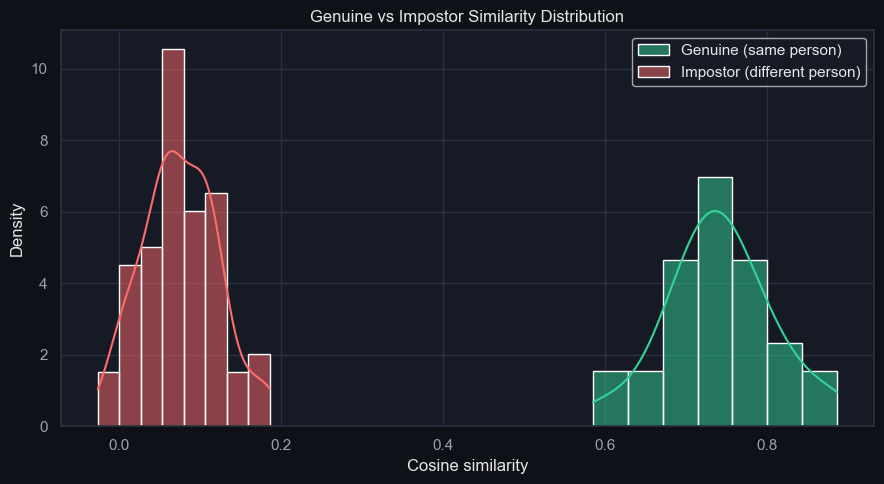

In [9]:
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


all_vectors = []
all_labels = []
for name, embeddings in records.items():
    for vec in embeddings:
        all_vectors.append(vec)
        all_labels.append(name)

all_vectors = np.stack(all_vectors)
n = len(all_vectors)

genuine_scores = []
impostor_scores = []

for i in range(n):
    for j in range(i + 1, n):
        sim = cosine_similarity(all_vectors[i], all_vectors[j])
        if all_labels[i] == all_labels[j]:
            genuine_scores.append(sim)
        else:
            impostor_scores.append(sim)

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

print(f"Genuine pairs: {len(genuine_scores)}  mean={genuine_scores.mean():.3f}  std={genuine_scores.std():.3f}")
print(f"Impostor pairs: {len(impostor_scores)}  mean={impostor_scores.mean():.3f}  std={impostor_scores.std():.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(genuine_scores, color=PALETTE[1], label="Genuine (same person)", kde=True, stat="density", alpha=0.5, ax=ax)
sns.histplot(impostor_scores, color=PALETTE[3], label="Impostor (different person)", kde=True, stat="density", alpha=0.5, ax=ax)
ax.set_xlabel("Cosine similarity")
ax.set_title("Genuine vs Impostor Similarity Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "similarity_distribution.png"), dpi=150, facecolor="#0E1117")
plt.show()

## 7. Threshold Calibration (FAR / FRR / EER)

For each candidate similarity threshold, we compute:

- False Accept Rate (FAR): fraction of impostor pairs scoring above the threshold.
- False Reject Rate (FRR): fraction of genuine pairs scoring below the threshold.

The Equal Error Rate (EER) point, where FAR equals FRR, is a standard reference for
picking an operating threshold. For an attendance system we generally prefer a lower
FAR (fewer wrong check-ins) even at the cost of a slightly higher FRR, since a rejected
genuine attempt simply falls back to manual verification.

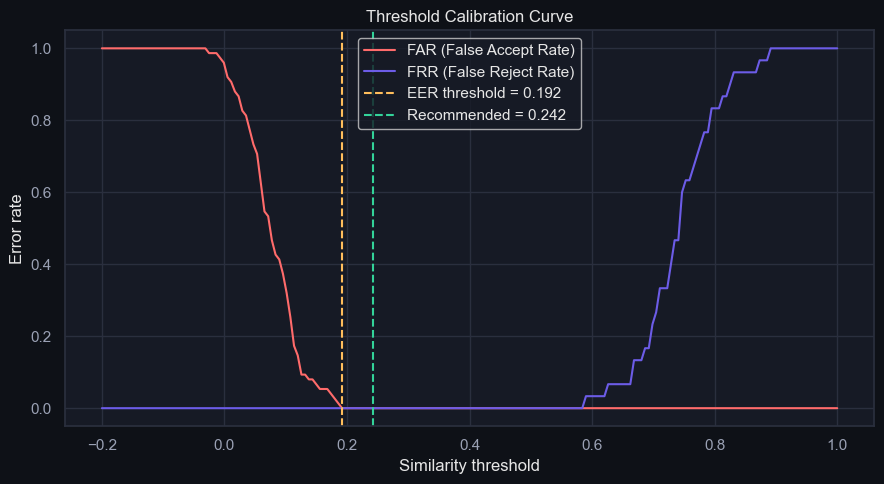

EER threshold: 0.192 (EER = 0.000%)
Recommended similarity threshold: 0.242


In [10]:
thresholds = np.linspace(-0.2, 1.0, 200)
far_list = []
frr_list = []

for t in thresholds:
    far = (impostor_scores >= t).mean() if len(impostor_scores) else 0.0
    frr = (genuine_scores < t).mean() if len(genuine_scores) else 0.0
    far_list.append(far)
    frr_list.append(frr)

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)
eer_idx = np.argmin(np.abs(far_arr - frr_arr))
eer_threshold = thresholds[eer_idx]
eer_value = (far_arr[eer_idx] + frr_arr[eer_idx]) / 2

recommended_threshold = float(np.clip(eer_threshold + 0.05, -0.2, 1.0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, far_arr, label="FAR (False Accept Rate)", color=PALETTE[3])
ax.plot(thresholds, frr_arr, label="FRR (False Reject Rate)", color=PALETTE[0])
ax.axvline(eer_threshold, color=PALETTE[2], linestyle="--", label=f"EER threshold = {eer_threshold:.3f}")
ax.axvline(recommended_threshold, color=PALETTE[1], linestyle="--", label=f"Recommended = {recommended_threshold:.3f}")
ax.set_xlabel("Similarity threshold")
ax.set_ylabel("Error rate")
ax.set_title("Threshold Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "threshold_calibration.png"), dpi=150, facecolor="#0E1117")
plt.show()

print(f"EER threshold: {eer_threshold:.3f} (EER = {eer_value:.3%})")
print(f"Recommended similarity threshold: {recommended_threshold:.3f}")

## 8. Mapping Similarity to a Confidence Percentage

The application shows a confidence percentage (target: 90 percent minimum for
auto-verification) rather than a raw cosine similarity. We linearly map similarity into
a 0-100 percent range using a calibrated lower and upper bound, then check what
similarity value corresponds to the desired confidence threshold.

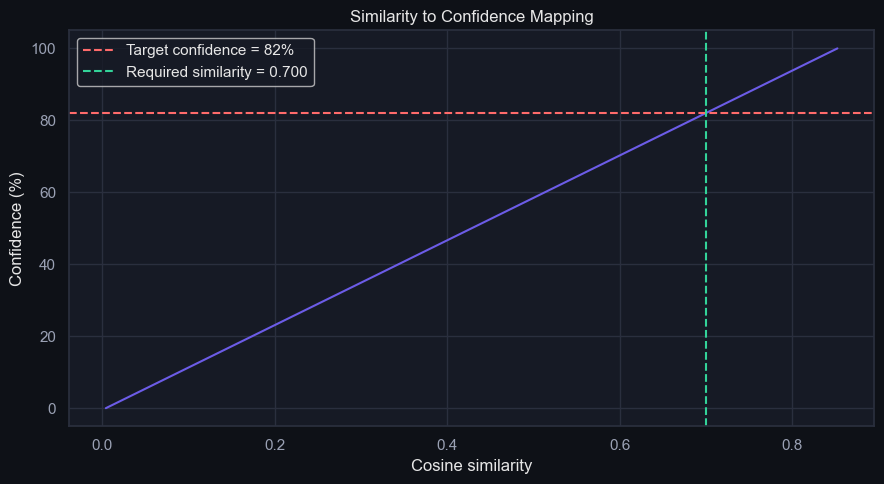

Calibration bounds: low=0.004, high=0.853
Similarity required to reach 82% confidence: 0.700


In [11]:
similarity_low_bound = float(np.percentile(impostor_scores, 5)) if len(impostor_scores) else 0.0
similarity_high_bound = float(np.percentile(genuine_scores, 95)) if len(genuine_scores) else 0.75

def similarity_to_confidence(sim, low, high):
    clipped = max(low, min(sim, high))
    return ((clipped - low) / (high - low)) * 100

target_confidence_percent = CONFIG["recognition"]["confidence_threshold_percent"]

sample_similarities = np.linspace(similarity_low_bound, similarity_high_bound, 50)
sample_confidences = [similarity_to_confidence(s, similarity_low_bound, similarity_high_bound) for s in sample_similarities]

required_similarity = similarity_low_bound + (target_confidence_percent / 100) * (similarity_high_bound - similarity_low_bound)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sample_similarities, sample_confidences, color=PALETTE[0])
ax.axhline(target_confidence_percent, color=PALETTE[3], linestyle="--", label=f"Target confidence = {target_confidence_percent:.0f}%")
ax.axvline(required_similarity, color=PALETTE[1], linestyle="--", label=f"Required similarity = {required_similarity:.3f}")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Confidence (%)")
ax.set_title("Similarity to Confidence Mapping")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confidence_mapping.png"), dpi=150, facecolor="#0E1117")
plt.show()

print(f"Calibration bounds: low={similarity_low_bound:.3f}, high={similarity_high_bound:.3f}")
print(f"Similarity required to reach {target_confidence_percent:.0f}% confidence: {required_similarity:.3f}")

## 9. Embedding Space Visualization (PCA and t-SNE)

Projects the 512-D embeddings into 2D to visually inspect how well identities cluster.
Tight, well separated clusters indicate the embedding space is discriminative for this
population.

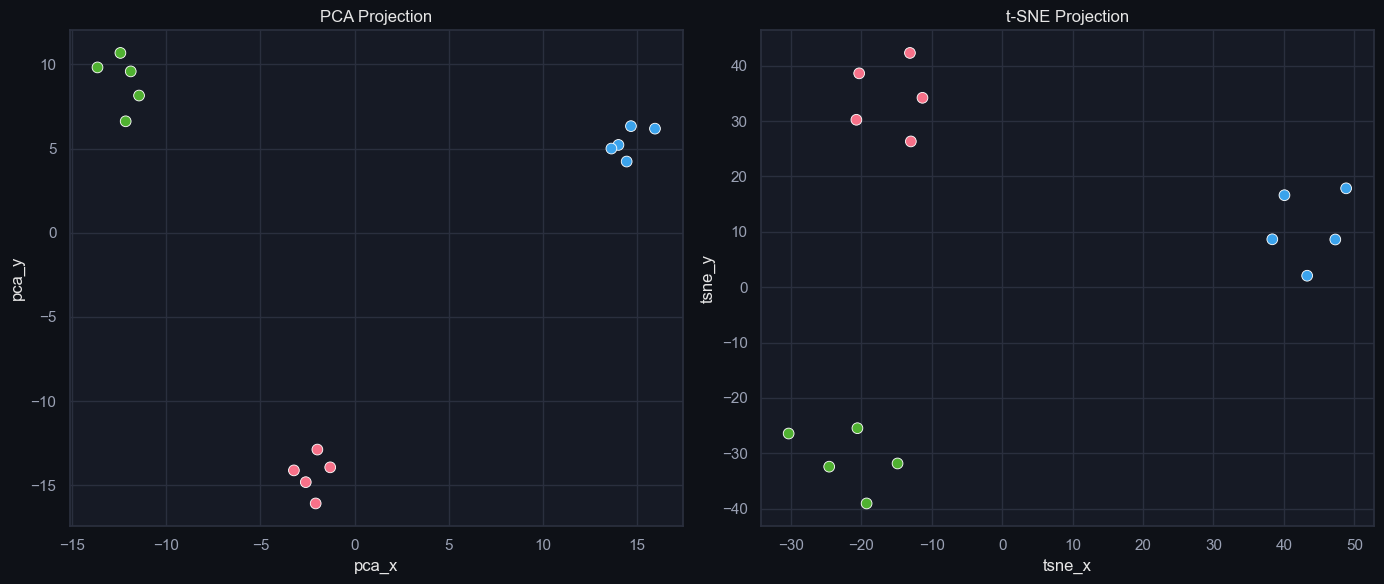

In [12]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(all_vectors)

n_samples = all_vectors.shape[0]
perplexity = max(5, min(30, n_samples // 3))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca")
tsne_coords = tsne.fit_transform(all_vectors)

plot_df = pd.DataFrame({
    "pca_x": pca_coords[:, 0], "pca_y": pca_coords[:, 1],
    "tsne_x": tsne_coords[:, 0], "tsne_y": tsne_coords[:, 1],
    "identity": all_labels,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=plot_df, x="pca_x", y="pca_y", hue="identity", palette="husl", s=60, ax=axes[0], legend=False)
axes[0].set_title("PCA Projection")
sns.scatterplot(data=plot_df, x="tsne_x", y="tsne_y", hue="identity", palette="husl", s=60, ax=axes[1], legend=False)
axes[1].set_title("t-SNE Projection")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "embedding_space.png"), dpi=150, facecolor="#0E1117")
plt.show()

## 10. Employee-to-Employee Similarity Heatmap

Average embedding per employee, then pairwise cosine similarity across all employees.
Bright off-diagonal cells flag identities that are unusually similar to each other and
may need more/better enrollment photos to separate them reliably.

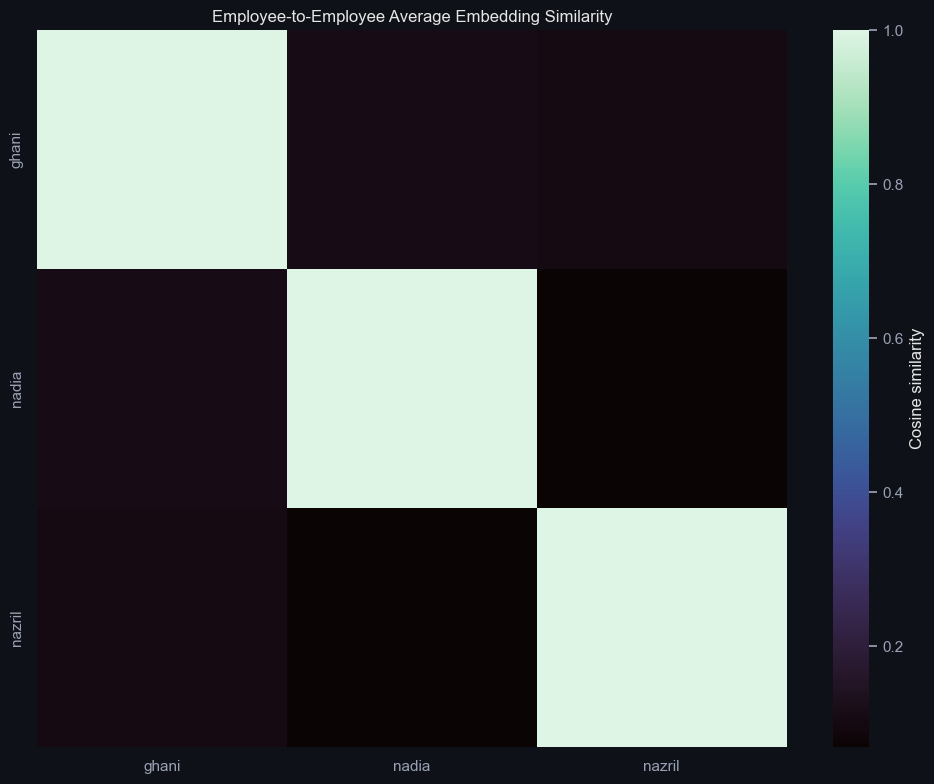

Most similar employee pair: ghani and nadia (similarity=0.110)


In [13]:
employee_names = list(records.keys())
avg_embeddings = np.stack([records[name].mean(axis=0) for name in employee_names])
avg_embeddings = avg_embeddings / np.linalg.norm(avg_embeddings, axis=1, keepdims=True)

sim_matrix = avg_embeddings @ avg_embeddings.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix, xticklabels=employee_names, yticklabels=employee_names,
    cmap="mako", ax=ax, cbar_kws={"label": "Cosine similarity"},
)
ax.set_title("Employee-to-Employee Average Embedding Similarity")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "employee_similarity_heatmap.png"), dpi=150, facecolor="#0E1117")
plt.show()

np.fill_diagonal(sim_matrix, -1)
most_similar_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
print(f"Most similar employee pair: {employee_names[most_similar_idx[0]]} and "
      f"{employee_names[most_similar_idx[1]]} (similarity={sim_matrix[most_similar_idx]:.3f})")

## 11. Simulated Recognition Test

Draws random probe embeddings (a held-out-style resample from each identity's
distribution), runs the same search + threshold logic used in the Streamlit app, and
reports overall accuracy plus a confusion matrix. This approximates end-to-end system
accuracy before wiring it into the backend.

Leave-one-out accuracy: 93.33%
Manual review rate: 6.67%


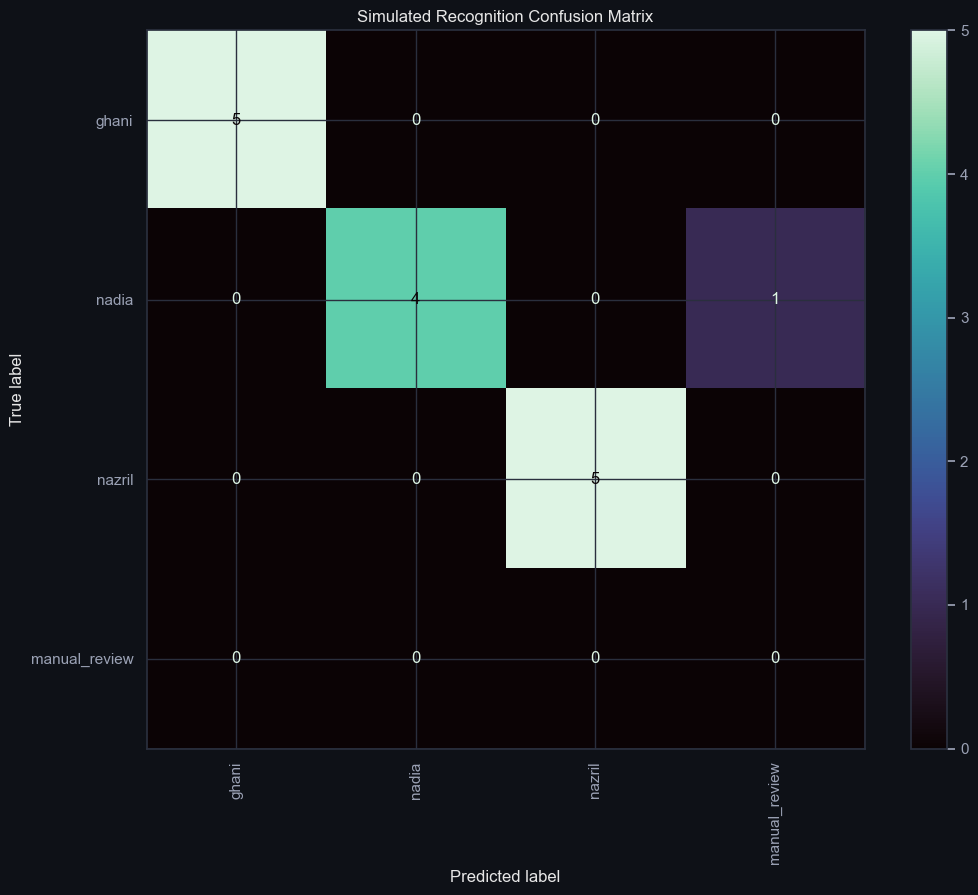

In [14]:
def search(probe, database_vectors, database_labels, top_k=1):
    sims = [cosine_similarity(probe, v) for v in database_vectors]
    order = np.argsort(sims)[::-1][:top_k]
    return [(database_labels[i], sims[i]) for i in order]


n_trials_per_employee = 20
true_labels = []
predicted_labels = []
trial_confidences = []

for idx in range(len(all_vectors)):
    probe = all_vectors[idx]
    true_label = all_labels[idx]

    gallery_vectors = np.delete(all_vectors, idx, axis=0)
    gallery_labels = [l for i, l in enumerate(all_labels) if i != idx]

    best_name, best_sim = search(probe, gallery_vectors, gallery_labels, top_k=1)[0]
    confidence = similarity_to_confidence(best_sim, similarity_low_bound, similarity_high_bound)

    true_labels.append(true_label)
    predicted_labels.append(best_name if confidence >= target_confidence_percent else "manual_review")
    trial_confidences.append(confidence)

accuracy = np.mean([t == p for t, p in zip(true_labels, predicted_labels)])
manual_rate = np.mean([p == "manual_review" for p in predicted_labels])
print(f"Leave-one-out accuracy: {accuracy:.2%}")
print(f"Manual review rate: {manual_rate:.2%}")

labels_for_matrix = employee_names + ["manual_review"]
cm = confusion_matrix(true_labels, predicted_labels, labels=labels_for_matrix)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_for_matrix)
disp.plot(ax=ax, cmap="mako", colorbar=True, xticks_rotation=90)
ax.set_title("Simulated Recognition Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confusion_matrix.png"), dpi=150, facecolor="#0E1117")
plt.show()

## 12. Export Calibration and Summary

In [15]:
calibration = {
    "data_mode": DATA_MODE,
    "similarity_low_bound": similarity_low_bound,
    "similarity_high_bound": similarity_high_bound,
    "recommended_similarity_threshold": recommended_threshold,
    "eer_threshold": float(eer_threshold),
    "eer_value": float(eer_value),
    "confidence_threshold_percent": target_confidence_percent,
    "required_similarity_for_target_confidence": float(required_similarity),
}

with open(CALIBRATION_PATH, "w") as f:
    json.dump(calibration, f, indent=2)

summary = {
    "data_mode": DATA_MODE,
    "num_employees": len(employee_names),
    "num_embeddings": int(n),
    "genuine_pairs": int(len(genuine_scores)),
    "impostor_pairs": int(len(impostor_scores)),
    "simulated_accuracy": float(accuracy),
    "simulated_manual_review_rate": float(manual_rate),
    "recommended_similarity_threshold": recommended_threshold,
    "confidence_threshold_percent": target_confidence_percent,
}

summary_path = os.path.join(OUTPUT_DIR, "embeddings", "pipeline_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Calibration saved to:", CALIBRATION_PATH)
print("Summary saved to:", summary_path)
print(json.dumps(summary, indent=2))

Calibration saved to: ..\output/embeddings/calibration.json
Summary saved to: ..\output\embeddings\pipeline_summary.json
{
  "data_mode": "real",
  "num_employees": 3,
  "num_embeddings": 15,
  "genuine_pairs": 30,
  "impostor_pairs": 75,
  "simulated_accuracy": 0.9333333333333333,
  "simulated_manual_review_rate": 0.06666666666666667,
  "recommended_similarity_threshold": 0.24195979899497483,
  "confidence_threshold_percent": 82.0
}


In [16]:
import shutil
import os

source = r"C:\Users\LENOVO\.insightface\models\buffalo_l"
destination = os.path.join("..", "output", "models", "buffalo_l")

shutil.copytree(source, destination, dirs_exist_ok=True)
print("Model files copied to:", os.path.abspath(destination))

Model files copied to: c:\Users\LENOVO\Documents\face-recognition-attendance\face-recognition-attendance\output\models\buffalo_l
